In [1]:
import pandas as pd
import numpy as np
import glob
import os
import sys
sys.path.insert(0, '../')
#sys.path.insert(0, './')
from data.Reinhard import Reinhard
from models.model_mrcnn import _default_mrcnn_config, build_default
from visualization.explain import ExplainPredictions
import torch
import tqdm
from PIL import Image
import torchvision
from torchmetrics.classification import MulticlassConfusionMatrix
import torchvision.ops.boxes as bops
from torchmetrics.classification import Dice
from PIL import Image
from skimage import draw
from skimage import measure
import plotly.express as px

In [2]:
dice = Dice(average='samples')
preds = torch.tensor([2, 0, 2, 1])
target = torch.tensor([1, 1, 2, 0])
dice(preds, target)

tensor(0.2500)

In [3]:
LBD_model_path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/models/mrcnn_models/woven-wood-253_mrcnn_model_24.pth'

In [4]:
test_config = dict(batch_size = 1, num_classes = 2)
model_config = _default_mrcnn_config(num_classes=1 + test_config['num_classes']).config
model_lbd = build_default(model_config, im_size=1024)

/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'backbone_name' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet152_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet152_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
model_lbd.load_state_dict(torch.load(LBD_model_path))

<All keys matched successfully>

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_lbd.eval().to(device)

GeneralizedRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.8198, 0.7572, 0.7618], std=[0.0848, 0.1066, 0.1211])
      Resize(min_size=(1024,), max_size=1024, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
   

In [7]:
def prepare_input(image):
    image_float_np = np.float32(image) / 255

    # define the torchvision image transforms
    transform = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
    ])
    input_tensor = transform(image)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    input_tensor = input_tensor.to(device)
    # Add a batch dimension:
    input_tensor = input_tensor.unsqueeze(0)
    return input_tensor, image_float_np

class_names = ['True', 'Pre']
def get_outputs(input_tensor, model, threshold):
    with torch.no_grad():
        # forward pass of the image through the modle
        outputs = model(input_tensor)
    #print(outputs)
    scores = list(outputs[0]['scores'].detach().cpu().numpy())
    # print("\n scores", max(scores))
    # index of those scores which are above a certain threshold
    thresholded_preds_inidices = [scores.index(i) for i in scores if i > threshold]
    #print(thresholded_preds_inidices)
    thresholded_preds_count = len(thresholded_preds_inidices)
    #print(thresholded_preds_count)
    scores = scores[:thresholded_preds_count]
    # get the masks
    masks = (outputs[0]['masks']>0.5).squeeze().detach().cpu().numpy()
    # print("masks", masks)
    # discard masks for objects which are below threshold
    masks = masks[:thresholded_preds_count]
    # get the bounding boxes, in (x1, y1), (x2, y2) format
    boxes = [[(int(i[0]), int(i[1])), (int(i[2]), int(i[3]))]  for i in outputs[0]['boxes'].detach().cpu()]
    # discard bounding boxes below threshold value
    boxes = boxes[:thresholded_preds_count]
    # get the classes labels
    # print('labels', outputs[0]['labels'])
    #print(outputs[0]['labels'])
    #print(thresholded_preds_count)
    #print(outputs[0]['labels'])
    labels = [class_names[i-1] for i in outputs[0]['labels']]
    #labels = [i for i in outputs[0]['labels']]
    #print(labels)
    labels = labels[:thresholded_preds_count]
    return masks, boxes, labels, scores

In [8]:
def expand_mask(mask_path):
    mask = Image.open(mask_path).convert('P')   
    mask = np.array(mask)
    # instances are encoded as different colors
    obj_ids = np.unique(mask)
    # first id is the background, so remove it
    obj_ids = obj_ids[1:]
    # split the color-encoded mask into a set
    # of binary masks
    masks = mask == obj_ids[:, None, None]
    num_objs = len(obj_ids)
    boxes = []
    for i in range(num_objs):
        pos = np.where(masks[i])
        xmin = np.min(pos[1])
        xmax = np.max(pos[1])
        ymin = np.min(pos[0])
        ymax = np.max(pos[0])
        #print(pos)
        if xmax <= xmin and ymax <=ymin:
            print("degenrate boxes", mask_path)
            print(len(obj_ids))
            break
        boxes.append([xmin, ymin, xmax, ymax])
    boxes = torch.as_tensor(boxes, dtype=torch.float32)
    x = [id // 50 for id in obj_ids]
    labels = torch.tensor(x)
    masks = torch.as_tensor(masks, dtype=torch.uint8)
    #image_id = torch.tensor([idx])
    area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
    # suppose all instances are not crowd
    iscrowd = torch.zeros((num_objs,), dtype=torch.int64)
    target = {}
    target["boxes"] = boxes
    target["labels"] = labels
    target["masks"] = masks
    #target["image_id"] = image_id
    target["area"] = area
    target["iscrowd"] = iscrowd
    return target

In [9]:
def match_mask(device,masked_image,binary_array):
    #num_classes = len(set(list(np.unique(masked_image)) +  list(np.unique(binary_array))))
    num_classes = 2
    metric = MulticlassConfusionMatrix(num_classes=num_classes).to(device)
    conf_final=torch.tensor(np.zeros((num_classes,num_classes))).to(device).to(torch.int64)
    for i in range(len(masked_image)):
        preds = torch.tensor(masked_image[i]).to(device).to(torch.int64)
        target = torch.tensor(binary_array[i]).to(device).to(torch.int64)
        a1 = metric(preds,target)
        conf_final = conf_final + a1     
    conf_final_np = conf_final.cpu().numpy()
    total_predicted = np.sum(conf_final_np, axis=0) 
    diag_elements = np.diag(conf_final_np)
    precision = diag_elements/total_predicted
    total_actual = np.sum(conf_final_np, axis=1) 
    recall = diag_elements/total_actual
    f1_score = (2*precision*recall)/(recall+precision)
    iou_coeff = (diag_elements)/(total_predicted+total_actual-diag_elements)
    
    #csv_filename_tosave = "Eval_Metric_"+ geofile.split(".")[0] + ".csv"
    eval_metrics = pd.DataFrame({"Class":["Background","Pre/True"],"Precision":precision, "recall":recall,"f1_score":f1_score,"iou_coeff":iou_coeff})
    #eval_metrics.to_csv(os.path.join(eval_dir,csv_filename_tosave))
    return eval_metrics[eval_metrics["Class"]=="Pre/True"]["f1_score"].values[0]

In [10]:
def match_label(pred_label, gt_label):
    if pred_label==gt_label:
        return True
    else:
        return False

def actual_label_target(gt_label):
    if (gt_label.cpu().numpy()==1):
        return "True"
    if (gt_label.cpu().numpy()==2):
        return "Pre"
    return None

In [ ]:
#test_folder  = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/Testing_results/ground_truth"
test_folder = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/LB_crops/patient_wise_crops_test"
image_folders = glob.glob(os.path.join(test_folder, '*.svs'))
output_df =  pd.DataFrame()
for image_folder in image_folders:
    images = glob.glob(os.path.join(image_folder, "images", "*.png"))
    masks = glob.glob(os.path.join(image_folder, "labels", "*.png"))
    images.sort()
    masks.sort()
    img_list = []
    target_mask_list= []
    pred_mask_list=[]
    f1_score_list = []
    matched_label_list = []
    actual_label_list = []
    pred_label_list =[]
    for img, mask in zip(images,masks):
        #img_name = os.path.basename(img).split('.')[0]
        image = np.array(Image.open(img))
        #mask = np.array(Image.open(mask))
        target = expand_mask(mask)
        if image.shape[2] == 4:
            image = image[:,:, :3]
        input_tensor, image_float_np = prepare_input(image)
        masks, boxes, labels, scores = get_outputs(input_tensor, model_lbd, 0.65)
        for i in range(len(target['masks'])):
            target_label = actual_label_target(target['labels'][i])
            for j in range(len(masks)):
                if len(masks[j].shape)>=2:
                    actual_label_list.append(target_label)
                    pred_label_list.append(labels[j])
                    f1_score = match_mask(device, masks[j],target['masks'][i])
                    print(f1_score)
                    matched_label = match_label(labels[j],target_label)
                    print(matched_label)
                    img_list.append(img)
                    target_mask_list.append(i)
                    pred_mask_list.append(j)
                    f1_score_list.append(f1_score)
                    matched_label_list.append(matched_label)
                    
    tmp = pd.DataFrame({"img_crop":img_list, "target_label":actual_label_list, "pred_label":pred_label_list, "target_mask_index":target_mask_list,"pred_mask_index":pred_mask_list, "dice/f1_score":f1_score_list,"matched_label":matched_label_list})
    tmp["image_folder"] = image_folder
    if len(output_df)==0:
        output_df = tmp
    else:
        output_df= pd.concat([output_df,tmp],ignore_index=True)


In [12]:
output_df["image_name"] =output_df["img_crop"].apply(lambda l:l.split("/")[-1])

In [7]:
output_folder = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/Testing_results/end2end_model_preds/woven-wood-253_mrcnn_model_24.pth_3uctrn1o10.pth_test_data2"

In [8]:
l = glob.glob(os.path.join(output_folder,"*.svs"))

In [9]:
l

['/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/Testing_results/end2end_model_preds/woven-wood-253_mrcnn_model_24.pth_3uctrn1o10.pth_test_data2/PD110_Syn1_TCx.svs',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/Testing_results/end2end_model_preds/woven-wood-253_mrcnn_model_24.pth_3uctrn1o10.pth_test_data2/14_133_FCx_aSyn_x200.svs',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/Testing_results/end2end_model_preds/woven-wood-253_mrcnn_model_24.pth_3uctrn1o10.pth_test_data2/PD268_Syn1_CG.svs',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/Testing_results/end2end_model_preds/woven-wood-253_mrcnn_model_24.pth_3uctrn1o10.pth_test_data2/16_044_PCx_aSyn_x200.svs']

In [107]:
#coords = pd.read_csv(os.path.join(l[3], "16_044_PCx_aSyn_x200.csv"))
#coords = pd.read_csv(os.path.join(l[2], "PD268_Syn1_CG.csv"))
coords = pd.read_csv(os.path.join(l[0], "PD110_Syn1_TCx.csv"))
#coords = pd.read_csv(os.path.join(l[1], "14_133_FCx_aSyn_x200.csv"))

In [108]:
coords[coords["confidence"]>0.65]

,Unnamed: 0,image_name,label,confidence,brown_pixels,True,Pre,False,centroid,eccentricity,area,equivalent_diameter,box_x1,box_x2,box_y1,box_y2,img_x,img_y
0,0,PD110_Syn1_TCx_1792_31232,Pre,0.657490,0,0,1,0,"(30.197183098591548, 31.37323943661972)",0.542297,142,13.446190,89,152,651,715,1792,31232
1,0,PD110_Syn1_TCx_3840_28160,True,0.693493,0,1,0,0,"(35.348101265822784, 34.81645569620253)",0.307542,316,20.058507,159,230,221,290,3840,28160
2,0,PD110_Syn1_TCx_4864_24064,Pre,0.911927,0,0,1,0,"(36.22959183673469, 33.69387755102041)",0.380072,196,15.797308,222,291,598,666,4864,24064
3,0,PD110_Syn1_TCx_4864_32256,True,0.881264,0,1,0,0,"(38.40353697749196, 36.765273311897104)",0.436989,622,28.141695,487,565,141,215,4864,32256
4,0,PD110_Syn1_TCx_4864_35328,Pre,0.944489,0,0,1,0,"(39.02777777777778, 34.76543209876543)",0.531682,324,20.310825,146,220,261,331,4864,35328
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,0,PD110_Syn1_TCx_40704_10752,Pre,0.755591,0,0,1,0,"(38.570048309178745, 36.36473429951691)",0.719813,414,22.959120,949,1024,939,1013,40704,10752
81,0,PD110_Syn1_TCx_40704_26112,True,0.854840,0,1,0,0,"(34.5, 34.42465753424658)",0.469910,292,19.281752,262,334,840,909,40704,26112
82,0,PD110_Syn1_TCx_40704_33280,True,0.822563,0,1,0,0,"(34.400696864111495, 34.63414634146341)",0.301076,287,19.115955,664,733,25,94,40704,33280
84,0,PD110_Syn1_TCx_41728_1536,True,0.793048,0,1,0,0,"(41.60424028268551, 37.003533568904594)",0.798939,566,26.844992,816,897,622,697,41728,1536


In [109]:
coords.sort_values(['img_x',
       'img_y'])

,Unnamed: 0,image_name,label,confidence,brown_pixels,True,Pre,False,centroid,eccentricity,area,equivalent_diameter,box_x1,box_x2,box_y1,box_y2,img_x,img_y
0,0,PD110_Syn1_TCx_1792_31232,Pre,0.657490,0,0,1,0,"(30.197183098591548, 31.37323943661972)",0.542297,142,13.446190,89,152,651,715,1792,31232
1,0,PD110_Syn1_TCx_3840_28160,True,0.693493,0,1,0,0,"(35.348101265822784, 34.81645569620253)",0.307542,316,20.058507,159,230,221,290,3840,28160
2,0,PD110_Syn1_TCx_4864_24064,Pre,0.911927,0,0,1,0,"(36.22959183673469, 33.69387755102041)",0.380072,196,15.797308,222,291,598,666,4864,24064
3,0,PD110_Syn1_TCx_4864_32256,True,0.881264,0,1,0,0,"(38.40353697749196, 36.765273311897104)",0.436989,622,28.141695,487,565,141,215,4864,32256
4,0,PD110_Syn1_TCx_4864_35328,Pre,0.944489,0,0,1,0,"(39.02777777777778, 34.76543209876543)",0.531682,324,20.310825,146,220,261,331,4864,35328
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,0,PD110_Syn1_TCx_40704_26112,True,0.854840,0,1,0,0,"(34.5, 34.42465753424658)",0.469910,292,19.281752,262,334,840,909,40704,26112
82,0,PD110_Syn1_TCx_40704_33280,True,0.822563,0,1,0,0,"(34.400696864111495, 34.63414634146341)",0.301076,287,19.115955,664,733,25,94,40704,33280
83,0,PD110_Syn1_TCx_40704_35328,Pre,0.627422,0,0,1,0,"(32.50322580645161, 37.480645161290326)",0.831044,310,19.867165,629,698,628,703,40704,35328
84,0,PD110_Syn1_TCx_41728_1536,True,0.793048,0,1,0,0,"(41.60424028268551, 37.003533568904594)",0.798939,566,26.844992,816,897,622,697,41728,1536


In [111]:
#david_coords = pd.read_csv(os.path.join(output_folder, l[1] ,"14_133_FCx_aSyn_x200.svs-points.csv"))
#david_coords = pd.read_csv(os.path.join(output_folder, l[3] ,"16_044_PCx_aSyn_x200.svs-points.csv"))
#david_coords = pd.read_csv(os.path.join(output_folder, l[2] ,"PD268_Syn1_CG.svs-points.csv"))
david_coords = pd.read_csv(os.path.join(output_folder, l[0] ,"PD110_Syn1_TCx.svs-points.csv"))


In [112]:
len(david_coords.sort_values(['x','y']).values)

115

In [113]:
def FindPoint(x1, y1, x2, 
              y2, x, y) :
    if (x > x1 and x < x2 and
        y > y1 and y < y2) :
        return True
    else :
        return False

In [114]:
def find_intersection(row):
    #x1,y1,x2,y2 =  row[5]-row[3], row[6]-row[1],row[5]+row[4],row[6]+row[2] 
    x1,y1,x2,y2 =  row["img_x"]-row["box_y1"], row["img_y"]-row["box_x1"],row["img_x"]+row["box_y2"],row["img_y"]+row["box_x2"] 
    for x,y in david_coords.sort_values(['x','y']).values:
        f = FindPoint(x1, y1, x2,  y2, x, y)
        if f:
            return True
    return False

In [115]:
coords["match"] = coords.apply(lambda l: find_intersection(l), axis=1) 

In [116]:
coords["match"].sum()

39

In [117]:
coords

,Unnamed: 0,image_name,label,confidence,brown_pixels,True,Pre,False,centroid,eccentricity,area,equivalent_diameter,box_x1,box_x2,box_y1,box_y2,img_x,img_y,match
0,0,PD110_Syn1_TCx_1792_31232,Pre,0.657490,0,0,1,0,"(30.197183098591548, 31.37323943661972)",0.542297,142,13.446190,89,152,651,715,1792,31232,False
1,0,PD110_Syn1_TCx_3840_28160,True,0.693493,0,1,0,0,"(35.348101265822784, 34.81645569620253)",0.307542,316,20.058507,159,230,221,290,3840,28160,True
2,0,PD110_Syn1_TCx_4864_24064,Pre,0.911927,0,0,1,0,"(36.22959183673469, 33.69387755102041)",0.380072,196,15.797308,222,291,598,666,4864,24064,False
3,0,PD110_Syn1_TCx_4864_32256,True,0.881264,0,1,0,0,"(38.40353697749196, 36.765273311897104)",0.436989,622,28.141695,487,565,141,215,4864,32256,False
4,0,PD110_Syn1_TCx_4864_35328,Pre,0.944489,0,0,1,0,"(39.02777777777778, 34.76543209876543)",0.531682,324,20.310825,146,220,261,331,4864,35328,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,0,PD110_Syn1_TCx_40704_26112,True,0.854840,0,1,0,0,"(34.5, 34.42465753424658)",0.469910,292,19.281752,262,334,840,909,40704,26112,True
82,0,PD110_Syn1_TCx_40704_33280,True,0.822563,0,1,0,0,"(34.400696864111495, 34.63414634146341)",0.301076,287,19.115955,664,733,25,94,40704,33280,True
83,0,PD110_Syn1_TCx_40704_35328,Pre,0.627422,0,0,1,0,"(32.50322580645161, 37.480645161290326)",0.831044,310,19.867165,629,698,628,703,40704,35328,True
84,0,PD110_Syn1_TCx_41728_1536,True,0.793048,0,1,0,0,"(41.60424028268551, 37.003533568904594)",0.798939,566,26.844992,816,897,622,697,41728,1536,False


In [118]:
len(coords[(coords["match"]==True) & (coords["confidence"]>=0.65)])

31

In [119]:
len(coords[(coords["confidence"]>=0.65)])

72

In [120]:
imgs = coords[(coords["match"]==False) & (coords["confidence"]>=0.65)]["image_name"].values

In [47]:
imgs = coords[(coords["match"]==True) & (coords["confidence"]>=0.9)]["image_name"].values

In [52]:
from PIL import Image
images = [np.asarray(Image.open(l[2]+"/detections/"+img+"_detection.png")) for img in imgs]

In [53]:
len(images)

30

In [103]:
import random
def Rand(start, end, num):
    res = []
 
    for j in range(num):
        res.append(np.random.randint(start, end))
 
    return res
 
 
# Driver Code
num = 4
start = 0
#end = 112
end = 29
img_to_pick = Rand(start, end, num)

In [104]:
img_to_pick = [images[i] for i in img_to_pick]

In [105]:
import matplotlib.pyplot as plt
import numpy as np

def show_images(images, cols = 1, titles = None):
    """Display a list of images in a single figure with matplotlib.
    
    Parameters
    ---------
    images: List of np.arrays compatible with plt.imshow.
    
    cols (Default = 1): Number of columns in figure (number of rows is 
                        set to np.ceil(n_images/float(cols))).
    
    titles: List of titles corresponding to each image. Must have
            the same length as titles.
    """
    assert((titles is None)or (len(images) == len(titles)))
    n_images = len(images)
    if titles is None: titles = ['Image (%d)' % i for i in range(1,n_images + 1)]
    fig = plt.figure()
    for n, (image, title) in enumerate(zip(images, titles)):
        a = fig.add_subplot(cols, int(np.ceil(n_images/float(cols))), n + 1)
        if image.ndim == 2:
            plt.gray()
        plt.imshow(image)
        #a.set_title(title)
    fig.set_size_inches(np.array(fig.get_size_inches()) * n_images)
    print(fig.get_size_inches())
    plt.show()


[25.6 19.2]


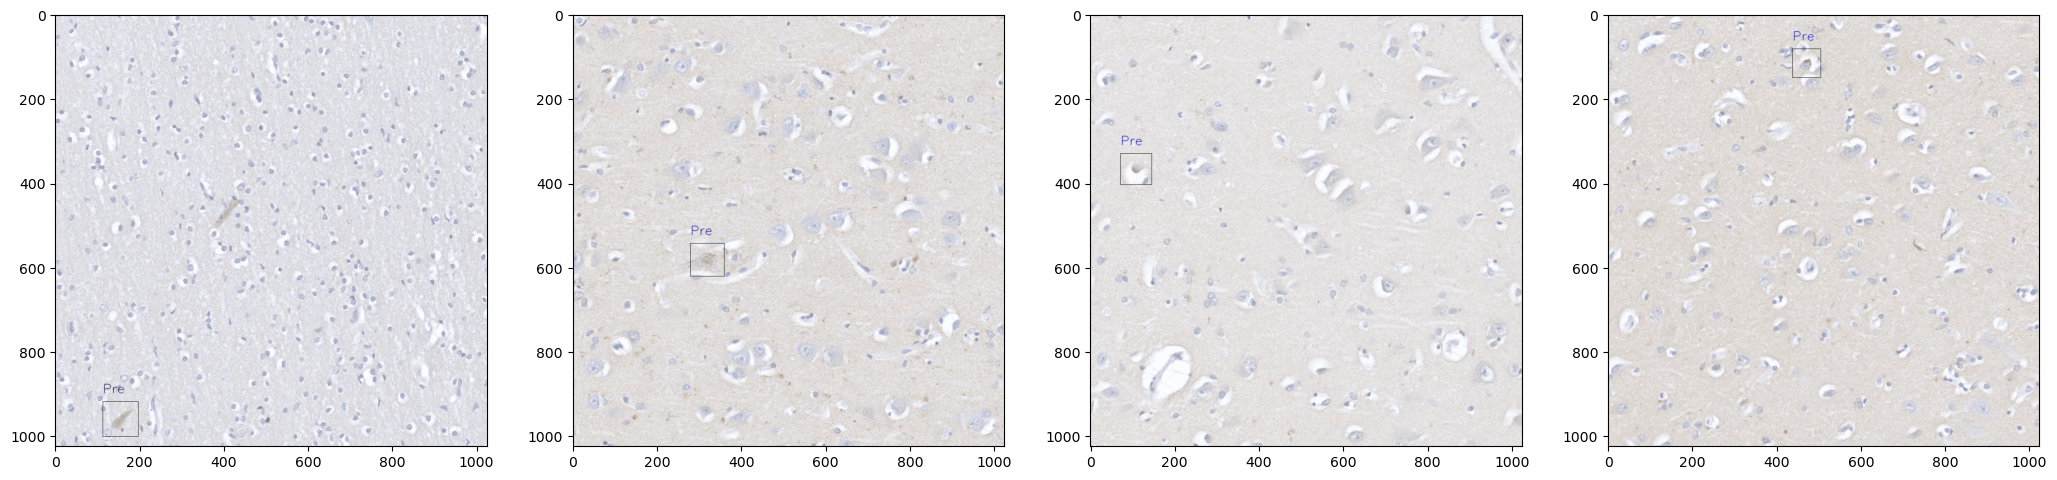

In [106]:
show_images(img_to_pick, cols = 1, titles = None)
#show_images(images, cols = 4, titles = None)

In [209]:
detections = pd.read_csv(os.path.join(output_folder, l[1], "14_133_FCx_aSyn_x200.csv"))

In [26]:
david_coords_pd = pd.DataFrame(david_coords.sort_values(['x','y']).values, columns=["x","y"])

In [27]:
david_coords_pd

,x,y
0,1234.712646,22520.308590
1,1614.242432,21730.431640
2,1819.734131,26031.005860
3,1854.890259,21622.427730
4,1974.540283,29678.367190
...,...,...
128,42162.003910,36373.054690
129,42267.312500,7033.155762
130,43371.113280,7650.639648
131,43973.195310,25540.828130


In [28]:
def find_matched_point(row):
    #coords1 = coords["image_name", "label",	"confidence", "box_x1", "box_x2", "box_y1", "box_y2", "img_x", "img_y"]
    coords["x1"] = coords["img_x"]-coords["box_y1"]
    coords["y1"] = coords["img_y"]-coords["box_x1"]
    coords["x2"] = coords["img_x"]+coords["box_y2"]
    coords["y2"] = coords["img_y"]+coords["box_x2"]
    x = row["x"]
    y = row["y"]
    for index, r in coords.iterrows():
        f = FindPoint(r["x1"], r["y1"], r["x2"], r["y2"], x, y)
        if f:
            return index
    return None

In [29]:
david_coords_pd["found_match"] = david_coords_pd.apply(lambda row: find_matched_point(row),axis=1)

In [34]:
david_coords_pd[david_coords_pd["found_match"].isna()][70:]

,x,y,found_match
92,31849.95117,5588.394043,NaN
93,31866.75586,31035.462890,NaN
95,32668.30273,5933.227051,NaN
99,33038.52734,12527.335940,NaN
100,33228.67969,12338.407230,NaN
101,33453.64844,12951.201170,NaN
102,34606.19531,37259.859380,NaN
106,36019.68750,19193.710940,NaN
109,36767.11719,39269.855470,NaN
112,37508.64844,39076.820310,NaN
